In [7]:
import os 
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image


In [8]:
# Image path 
train_dir = "C:\\Users\\ravi.dalal\\Desktop\\Python\\Projects\\Defect_Classification\\Datasets\\NEU-DET\\train\\images"

In [9]:
image_paths = []
labels = []

for class_name in os.listdir(train_dir):
    class_folder = os.path.join(train_dir, class_name)

    if os.path.isdir(class_folder):
        for image_name in os.listdir(class_folder):
            image_path = os.path.join(class_folder, image_name)

            image_paths.append(image_path)
            labels.append(class_name)

df = pd.DataFrame({
    'image_path' : image_paths,
    "label": labels
})



In [10]:
df.tail()

,image_path,label
1435,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,scratches
1436,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,scratches
1437,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,scratches
1438,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,scratches
1439,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,scratches


In [11]:
# Basic dataset overview:
print("Total images:", len(df))
print("Total classes:", df["label"].nunique())
print("class name:", df["label"].unique())



Total images: 1440
Total classes: 6
class name: <StringArray>
[        'crazing',       'inclusion',         'patches',  'pitted_surface',
 'rolled-in_scale',       'scratches']
Length: 6, dtype: str


In [12]:
# class count
class_count = df["label"].value_counts()
class_count

label
crazing            240
inclusion          240
patches            240
pitted_surface     240
rolled-in_scale    240
scratches          240
Name: count, dtype: int64

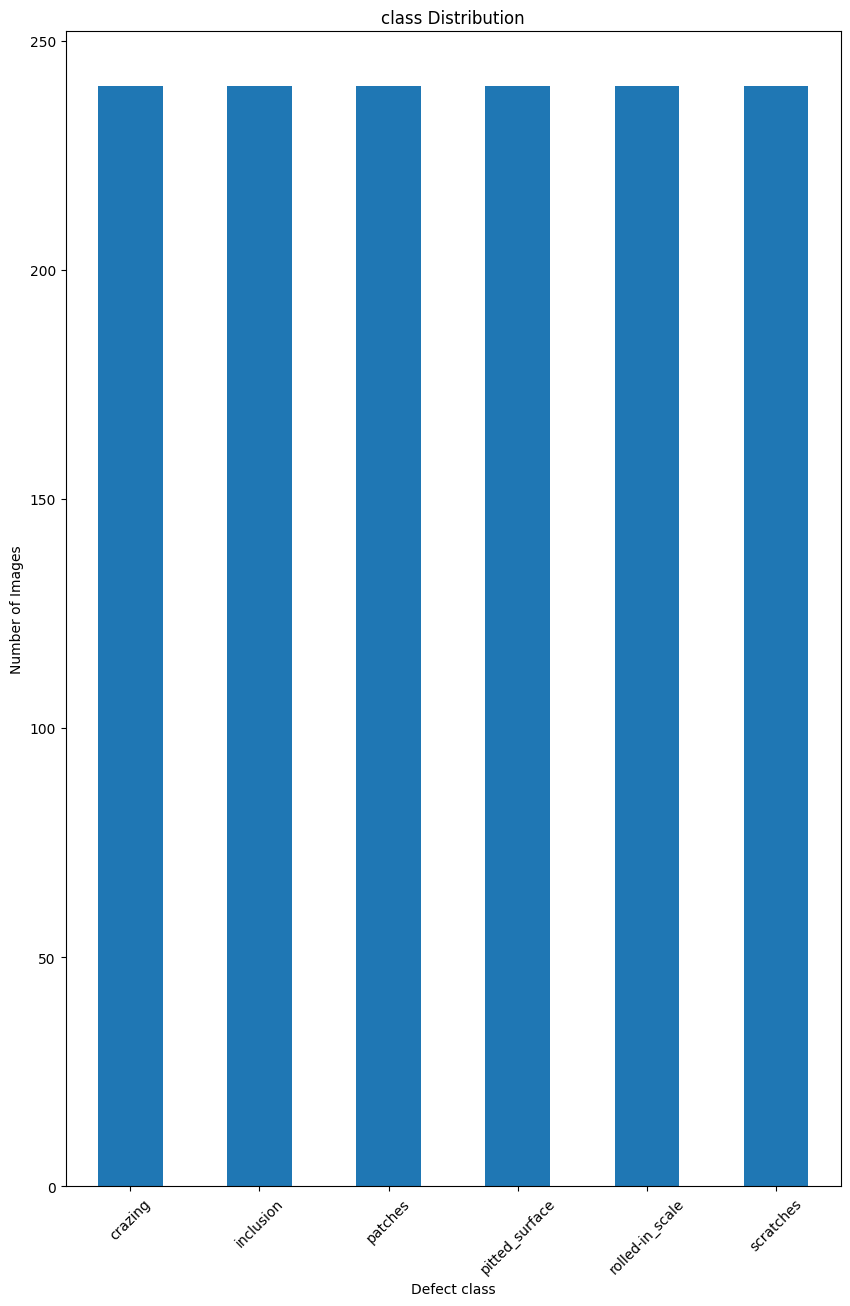

In [13]:
# plot class distribution:
plt.figure(figsize=(10, 15))
class_count.plot(kind="bar")
plt.title("class Distribution")
plt.xlabel("Defect class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

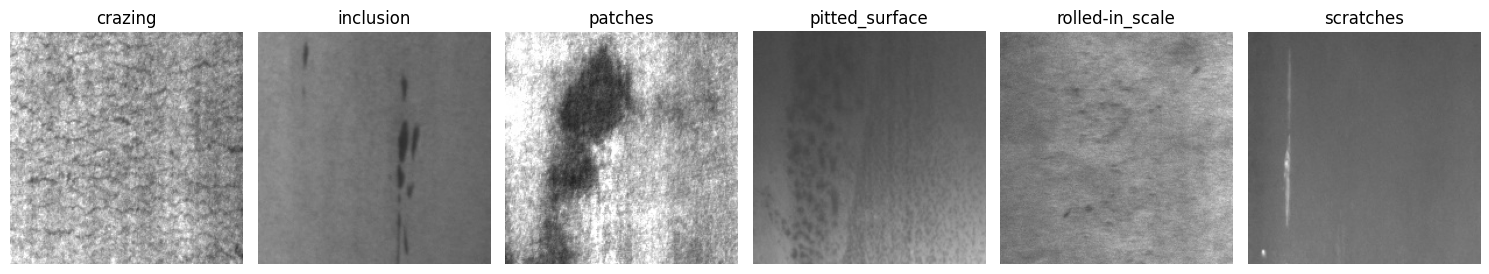

In [17]:
# Display one image from each class:

plt.figure(figsize=(15, 5))

for i, class_name in enumerate(df["label"].unique()):
    sample_path = df[df["label"] == class_name]["image_path"].iloc[0]

    img = Image.open(sample_path)

    plt.subplot(1, df["label"].nunique(), i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')


plt.tight_layout()
plt.show



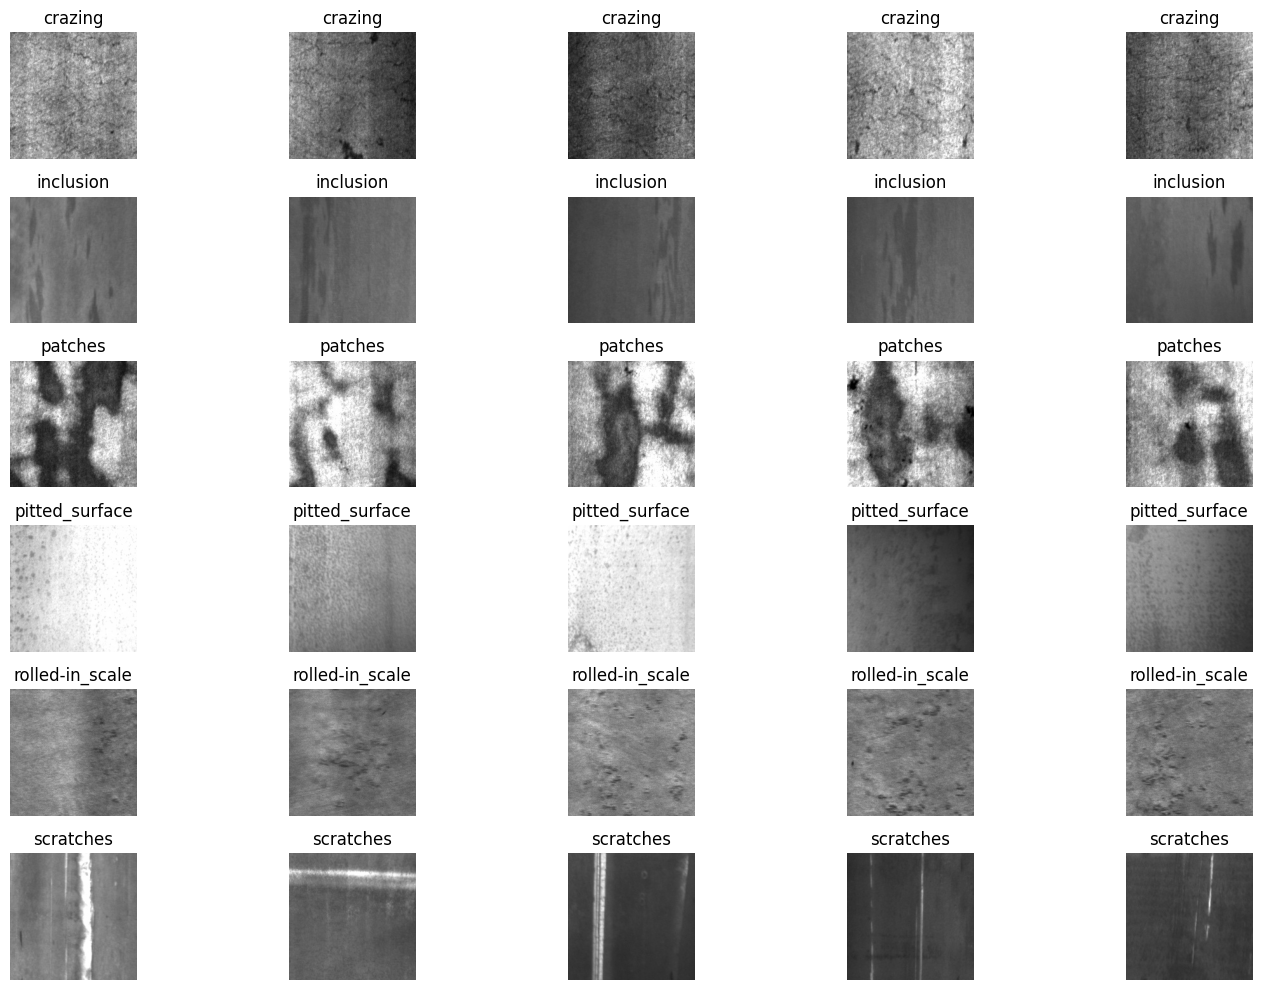

In [18]:
# Display random images from each class
plt.figure(figsize=(15, 10))

plot_index = 1

for class_name in df["label"].unique():
    sample_paths = df[df["label"] == class_name]["image_path"].sample(5, random_state=42)

    for path in sample_paths:
        img = Image.open(path)

        plt.subplot(df["label"].nunique(), 5, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [ ]:
# Check image size:
widths = []
heights = []
channels = []

for path in df["image_path"]:
    img = Image.open(path)

    widths.append(img.size[0])
    heights.append(img.size[1])
    channels.append(img.mode)

df["width"] = widths
df["height"] = heights
df["mode"] = channels

df.head()

,image_path,label,width,height,mode
0,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,crazing,200,200,RGB
1,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,crazing,200,200,RGB
2,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,crazing,200,200,RGB
3,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,crazing,200,200,RGB
4,C:\Users\ravi.dalal\Desktop\Python\Projects\De...,crazing,200,200,RGB


In [ ]:
# Image size summary
print("Unique widths:", df["width"].unique())
print("Unique heights:", df["height"].unique())
print("Image modes:", df["mode"].value_counts())

Unique widths: [200]
Unique heights: [200]
Image modes: mode
RGB    1440
Name: count, dtype: int64


In [21]:
# Chech corrupted images
corrupted_images = []

for path in df["image_path"]:
    try:
        img = Image.open(path)
        img.verify()
    except Exception as e:
        corrupted_images.append(path)

print("Corrupted images:", len(corrupted_images))
corrupted_images[:10]

Corrupted images: 0


[]

In [22]:
# Check duplicate image paths:
print("Duplicate paths:", df["image_path"].duplicated().sum())

Duplicate paths: 0


In [23]:
# Save EDA dataframe:
df.to_csv("neu_eda_metadata.csv", index=False)

## EDA Summary

The NEU Surface Defect Dataset contains 6 steel surface defect classes.  
Class distribution was checked to verify whether the dataset is balanced.  
Sample images from each class were visualized to understand defect patterns.  
Image dimensions and color modes were checked for preprocessing decisions.  
Corrupted and duplicate image paths were checked before model training.

Based on EDA, images will be resized to 224×224 and normalized before CNN/transfer learning model training.

In [ ]:
from sklearn.model